# The Smart Doctor
## AI-Powered Skin Cancer Detection & Medical Consultation

Skin cancer is one of the most common cancers worldwide, and early detection dramatically improves patient outcomes. Yet accurately classifying skin lesions requires years of clinical training, and even experts sometimes disagree on borderline cases.

This project builds the core components of an intelligent medical AI system:

1. **Vision Diagnostics** — Fine-tune ResNet-18 and ViT-Base-16 on dermoscopic images and compare their performance on the 7-class DermaMNIST dataset.
2. **Explainability** — Apply GradCAM and Attention Rollout to understand what each model "sees" when making a prediction — a critical requirement for clinical trust.
3. **Medical LLM (LoRA)** — Fine-tune Gemma-3-270M-IT on the MedMCQA dataset using LoRA so the system can answer medical questions without retraining all parameters.
4. **RAG Pipeline** — Augment the LLM with a retrieval layer backed by recent medical papers, grounding answers in up-to-date evidence rather than model memory alone.

## Environment Setup

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from tqdm.notebook import tqdm
import functools
import cv2
import medmnist
from medmnist import INFO
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from typing import Tuple
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize

from huggingface_hub import login
from datasets import load_dataset, DatasetDict
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
import re, json, random, wandb

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__} | MedMNIST {medmnist.__version__}")
print(f"CUDA: {torch.cuda.is_available()} | MPS: {torch.backends.mps.is_available()}")

PyTorch 2.12.0 | MedMNIST 3.0.2
CUDA: False | MPS: True


In [3]:
base_dir = "./outputs"
os.makedirs(base_dir, exist_ok=True)
skip_training = True  # set False to retrain from scratch
print(f"Outputs: {os.path.abspath(base_dir)}")

Outputs: /Users/divyanshpurohit/Desktop/Acad/Q3/Machine Learning Engineering/Assignments/The Smart Doctor/outputs


## 1. Vision Diagnostics: CNNs vs. Vision Transformers

We compare two established architectures for skin lesion classification:
- **ResNet-18** — a classic CNN that learns hierarchical local features through convolutional filters.
- **ViT-Base-16** — a Vision Transformer that splits the image into 16×16 patches and models global relationships via self-attention.

Both are pre-trained on ImageNet and fine-tuned on **DermaMNIST**, a benchmark derived from the HAM10000 dermatology dataset.

In [4]:
if torch.cuda.is_available():
    _device = "cuda"
elif torch.backends.mps.is_available():
    _device = "mps"
else:
    _device = "cpu"

CONFIG = {
    "data_flag": "dermamnist",
    "download": True,
    "size": 224,
    "batch_size": 64,
    "num_epochs": 15,
    "learning_rate": 1e-3,
    "num_workers": 0,
    "device": _device,
}
print(f"Device: {CONFIG['device']} | Image size: {CONFIG['size']}px | Epochs: {CONFIG['num_epochs']}")

Device: mps | Image size: 224px | Epochs: 15


In [5]:
def get_data_loaders(batch_size: int = 64) -> Tuple[DataLoader, DataLoader, DataLoader, int]:
    info = INFO['dermamnist']
    n_classes = len(info['label'])
    DataClass = getattr(medmnist, info['python_class'])

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    # Dermoscopic images are rotation-invariant and exhibit natural colour/lighting variation.
    # Augmentation simulates different dermatoscopes, capture angles, and skin tones.
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        normalize,
    ])
    eval_transform = transforms.Compose([transforms.ToTensor(), normalize])

    train_dataset = DataClass(split='train', transform=train_transform, download=True, size=224)
    val_dataset   = DataClass(split='val',   transform=eval_transform,  download=True, size=224)
    test_dataset  = DataClass(split='test',  transform=eval_transform,  download=True, size=224)

    def collate_fn(batch):
        images, labels = zip(*batch)
        images = torch.stack(images)
        labels = torch.tensor(
            [l.item() if hasattr(l, 'item') else l.flatten()[0] if hasattr(l, 'flatten') else l
             for l in labels], dtype=torch.long)
        return images, labels

    kw = dict(batch_size=batch_size, num_workers=CONFIG["num_workers"], collate_fn=collate_fn)
    train_loader = DataLoader(train_dataset, shuffle=True,  **kw)
    val_loader   = DataLoader(val_dataset,   shuffle=False, **kw)
    test_loader  = DataLoader(test_dataset,  shuffle=False, **kw)

    print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
    return train_loader, val_loader, test_loader, n_classes

train_loader, val_loader, test_loader, n_classes = get_data_loaders(CONFIG['batch_size'])
class_names = {i: INFO['dermamnist']['label'][str(i)] for i in range(n_classes)}

Train: 7,007 | Val: 1,003 | Test: 2,005


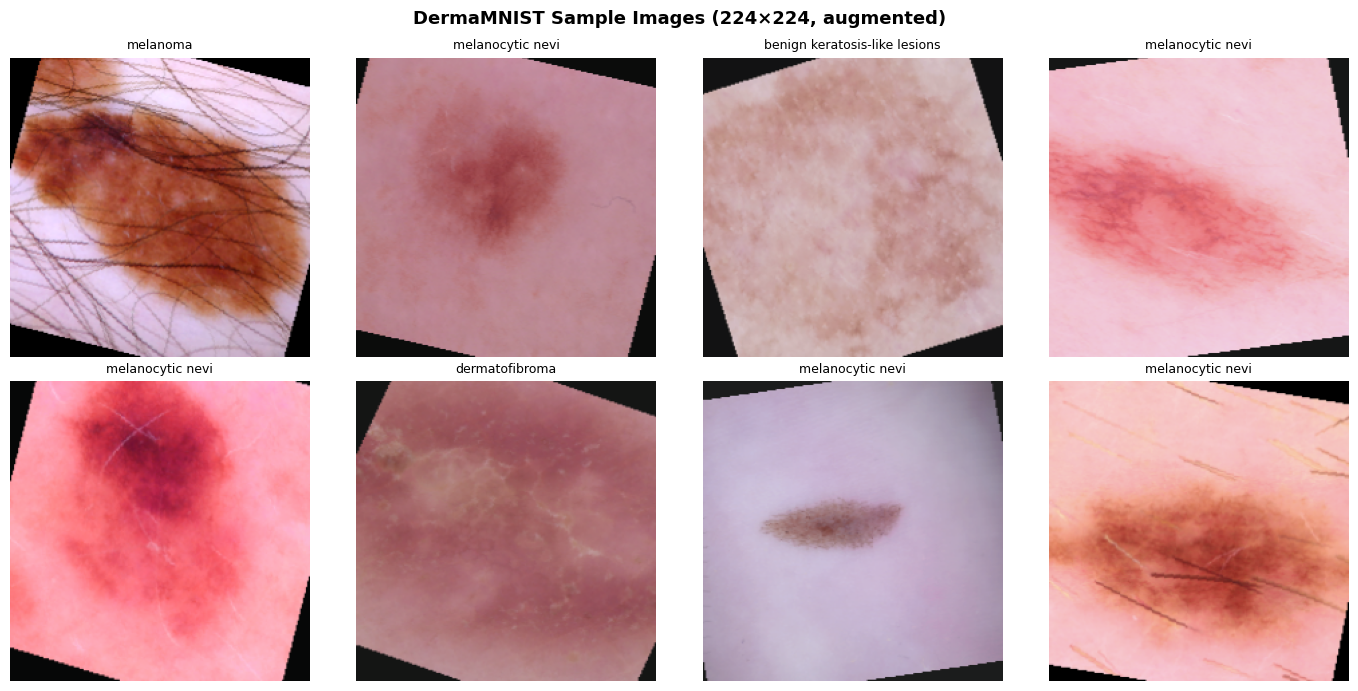

In [6]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.ravel()):
    img = images[i].numpy().transpose((1, 2, 0))
    img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("DermaMNIST Sample Images (224×224, augmented)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Shared Training Infrastructure

In [7]:
def evaluate(model, data_loader, criterion=None, device='cuda'):
    model.eval()
    all_preds, all_labels = [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Evaluating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if criterion is not None:
                running_loss += criterion(outputs, labels).item()
            all_preds.extend(outputs.max(1)[1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy   = 100. * (all_preds == all_labels).sum() / len(all_labels)
    avg_loss   = running_loss / len(data_loader) if criterion is not None else None
    print(f"Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, accuracy, avg_loss


def plot_training_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train', linewidth=2)
    ax1.plot(history['val_loss'],   label='Val',   linewidth=2)
    ax1.set(xlabel='Epoch', ylabel='Loss', title=f'{model_name} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(history['train_acc'], label='Train', linewidth=2)
    ax2.plot(history['val_acc'],   label='Val',   linewidth=2)
    ax2.set(xlabel='Epoch', ylabel='Accuracy (%)', title=f'{model_name} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f'{model_name}_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, class_names_dict, model_name):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, title in zip(axes,
        [cm, cm_norm], ['d', '.2f'],
        [f'{model_name} — Counts', f'{model_name} — Normalized']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=class_names_dict.values(),
                    yticklabels=class_names_dict.values())
        ax.set(title=title, xlabel='Predicted', ylabel='True')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f'{model_name}_confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
import time

def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_path = os.path.join(base_dir, f'{model_name}_best.pth')

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f'{running_loss/len(train_loader):.4f}',
                             acc=f'{100.*correct/total:.2f}%')

        train_loss = running_loss / len(train_loader)
        train_acc  = 100. * correct / total
        _, _, val_acc, val_loss = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        scheduler.step()
        print(f'Epoch {epoch+1}: train={train_acc:.2f}% val={val_acc:.2f}%')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f'  → saved checkpoint (val={val_acc:.2f}%)')

    print(f'Best validation accuracy: {best_val_acc:.2f}%')
    return history, best_path

### 1.3 ResNet-18

In [9]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, n_classes)
resnet_model = resnet_model.to(CONFIG['device'])

total     = sum(p.numel() for p in resnet_model.parameters())
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"ResNet-18 — total: {total:,} | trainable: {trainable:,}")

ResNet-18 — total: 11,180,103 | trainable: 11,180,103


In [10]:
resnet_checkpoint = os.path.join(base_dir, 'resnet18_best.pth')

if skip_training and os.path.exists(resnet_checkpoint):
    resnet_model.load_state_dict(torch.load(resnet_checkpoint, map_location=CONFIG['device']))
    print(f'Loaded ResNet-18 from checkpoint.')
    resnet_history, resnet_train_time = None, None
else:
    t0 = time.time()
    resnet_history, resnet_checkpoint = train_model(
        resnet_model, train_loader, val_loader,
        num_epochs=CONFIG['num_epochs'], learning_rate=CONFIG['learning_rate'],
        device=CONFIG['device'], model_name='resnet18')
    resnet_train_time = time.time() - t0
    print(f'ResNet-18 training time: {resnet_train_time:.1f}s')

Loaded ResNet-18 from checkpoint.


In [11]:
if resnet_history is not None:
    plot_training_history(resnet_history, 'ResNet-18')

In [12]:
resnet_model.load_state_dict(torch.load(resnet_checkpoint, map_location=CONFIG['device']))
resnet_test_preds, resnet_test_labels, resnet_test_acc, _ = evaluate(
    resnet_model, test_loader, device=CONFIG['device'])

print(f'ResNet-18 Test Accuracy: {resnet_test_acc:.2f}%')
print(classification_report(resnet_test_labels, resnet_test_preds,
                             target_names=list(class_names.values()), digits=4))

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 84.99%
ResNet-18 Test Accuracy: 84.99%
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma     0.8529    0.4394    0.5800        66
                           basal cell carcinoma     0.7027    0.7573    0.7290       103
                  benign keratosis-like lesions     0.7467    0.7773    0.7617       220
                                 dermatofibroma     0.6316    0.5217    0.5714        23
                                       melanoma     0.6337    0.5740    0.6024       223
                               melanocytic nevi     0.9150    0.9389    0.9268      1341
                               vascular lesions     0.7941    0.9310    0.8571        29

                                       accuracy                         0.8499      2005
                                      macro avg     0.7538    0.7057    0.7183      2005
                                   weighted avg     0.8473 

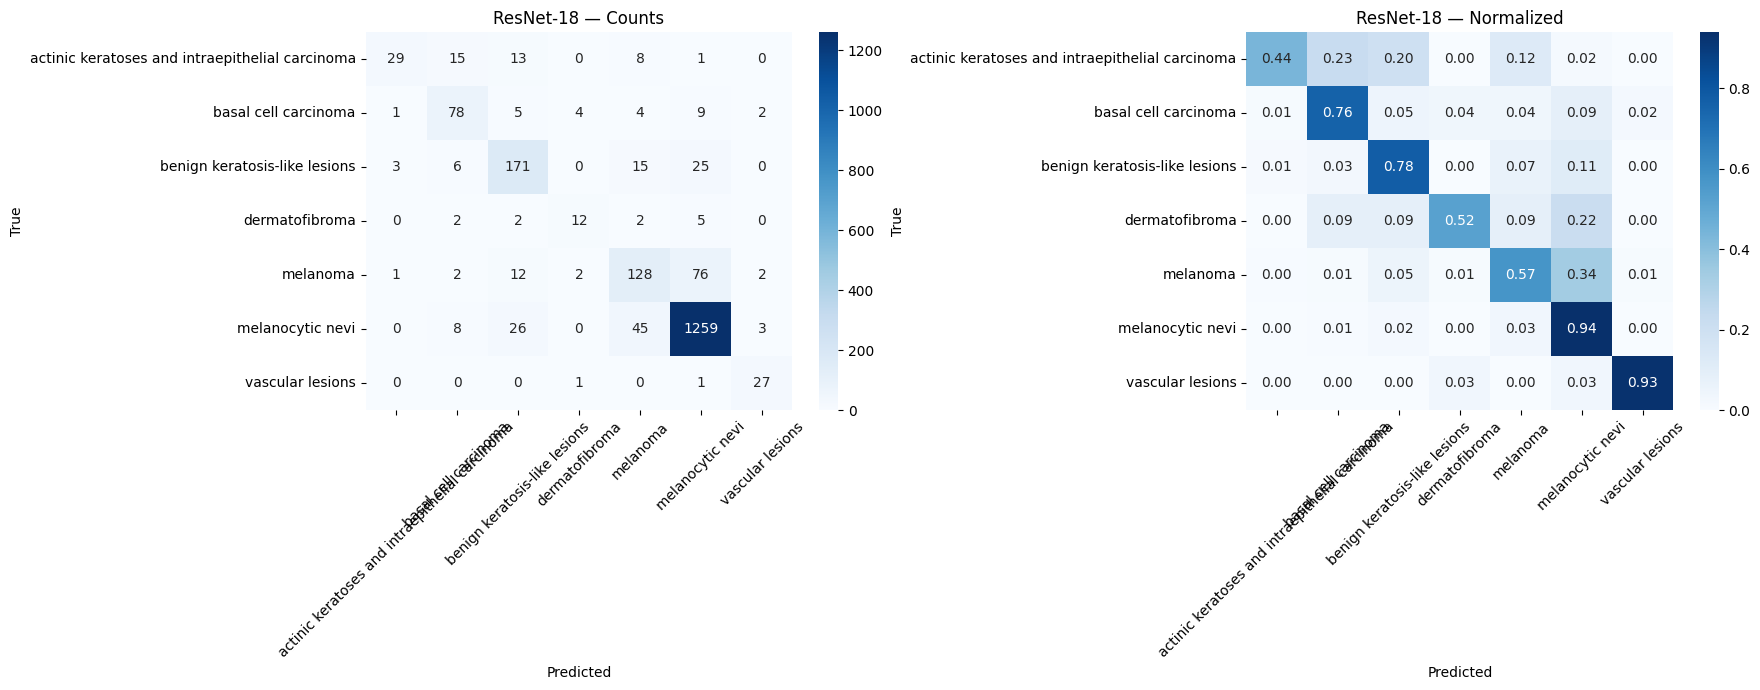

In [13]:
plot_confusion_matrix(resnet_test_labels, resnet_test_preds, class_names, 'ResNet-18')

### 1.4 ViT-Base-16

ViT-Base-16 is significantly larger (~86M parameters vs. ~11M for ResNet-18) and benefits from a lower learning rate due to its pre-trained attention patterns. We use the same training loop for a fair comparison.

In [14]:
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, n_classes)
vit_model = vit_model.to(CONFIG['device'])

total     = sum(p.numel() for p in vit_model.parameters())
trainable = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ViT-Base-16 — total: {total:,} | trainable: {trainable:,}")

ViT-Base-16 — total: 85,804,039 | trainable: 85,804,039


In [15]:
vit_checkpoint = os.path.join(base_dir, 'vit_b16_best.pth')

if skip_training and os.path.exists(vit_checkpoint):
    vit_model.load_state_dict(torch.load(vit_checkpoint, map_location=CONFIG['device']))
    print('Loaded ViT-Base-16 from checkpoint.')
    vit_history, vit_train_time = None, None
else:
    t0 = time.time()
    vit_history, vit_checkpoint = train_model(
        vit_model, train_loader, val_loader,
        num_epochs=CONFIG['num_epochs'], learning_rate=1e-4,  # lower LR for ViT
        device=CONFIG['device'], model_name='vit_b16')
    vit_train_time = time.time() - t0
    print(f'ViT-Base-16 training time: {vit_train_time:.1f}s')

Loaded ViT-Base-16 from checkpoint.


In [16]:
if vit_history is not None:
    plot_training_history(vit_history, 'ViT-Base-16')

In [17]:
vit_model.load_state_dict(torch.load(vit_checkpoint, map_location=CONFIG['device']))
vit_test_preds, vit_test_labels, vit_test_acc, _ = evaluate(
    vit_model, test_loader, device=CONFIG['device'])

print(f'ViT-Base-16 Test Accuracy: {vit_test_acc:.2f}%')
print(classification_report(vit_test_labels, vit_test_preds,
                             target_names=list(class_names.values()), digits=4))

Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 88.38%
ViT-Base-16 Test Accuracy: 88.38%
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma     0.8636    0.5758    0.6909        66
                           basal cell carcinoma     0.7459    0.8835    0.8089       103
                  benign keratosis-like lesions     0.7276    0.8136    0.7682       220
                                 dermatofibroma     0.9474    0.7826    0.8571        23
                                       melanoma     0.7600    0.6816    0.7187       223
                               melanocytic nevi     0.9434    0.9441    0.9437      1341
                               vascular lesions     0.8750    0.9655    0.9180        29

                                       accuracy                         0.8838      2005
                                      macro avg     0.8376    0.8067    0.8151      2005
                                   weighted avg     0.885

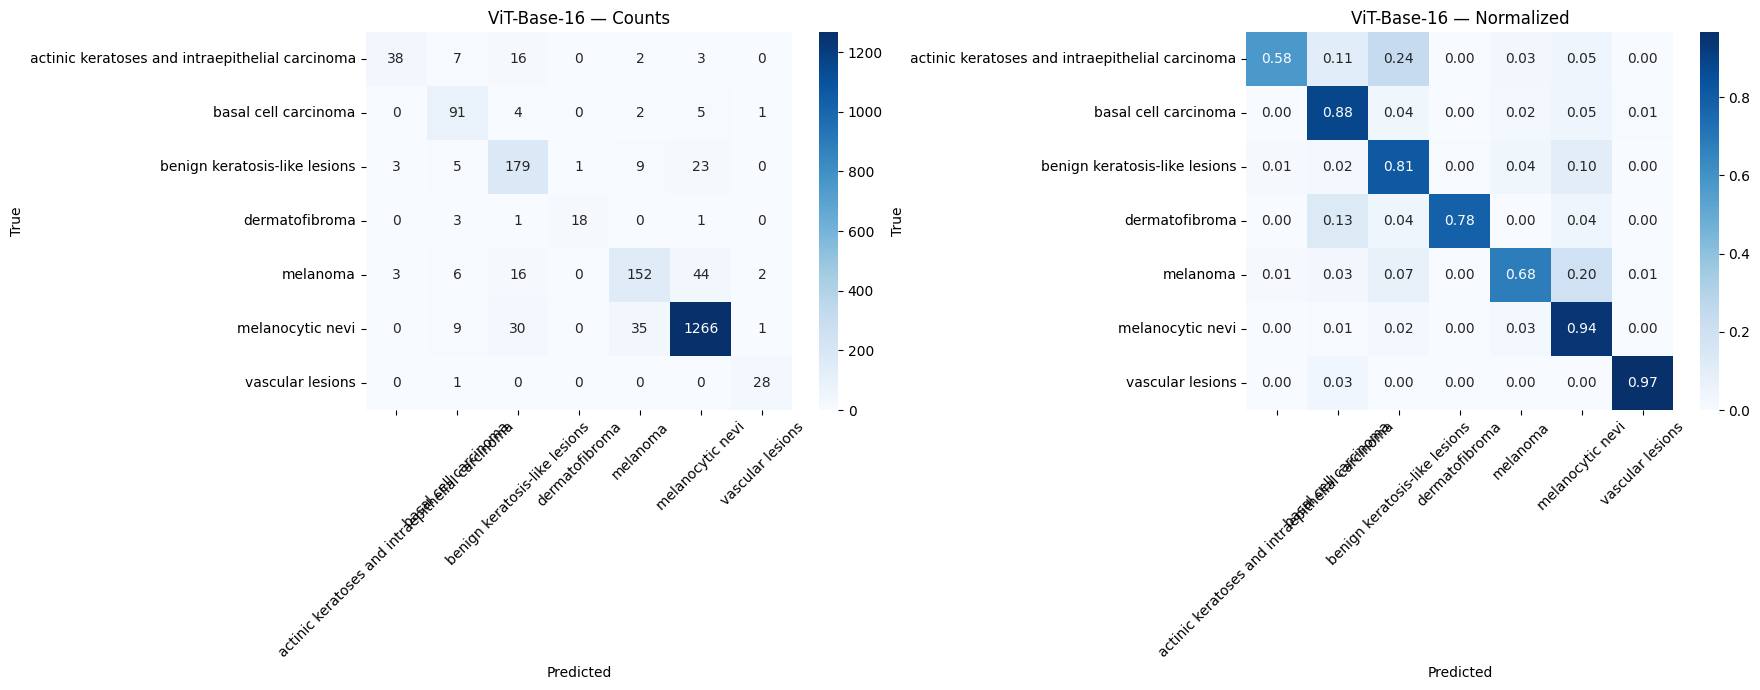

In [18]:
plot_confusion_matrix(vit_test_labels, vit_test_preds, class_names, 'ViT-Base-16')

### 1.5 Model Comparison

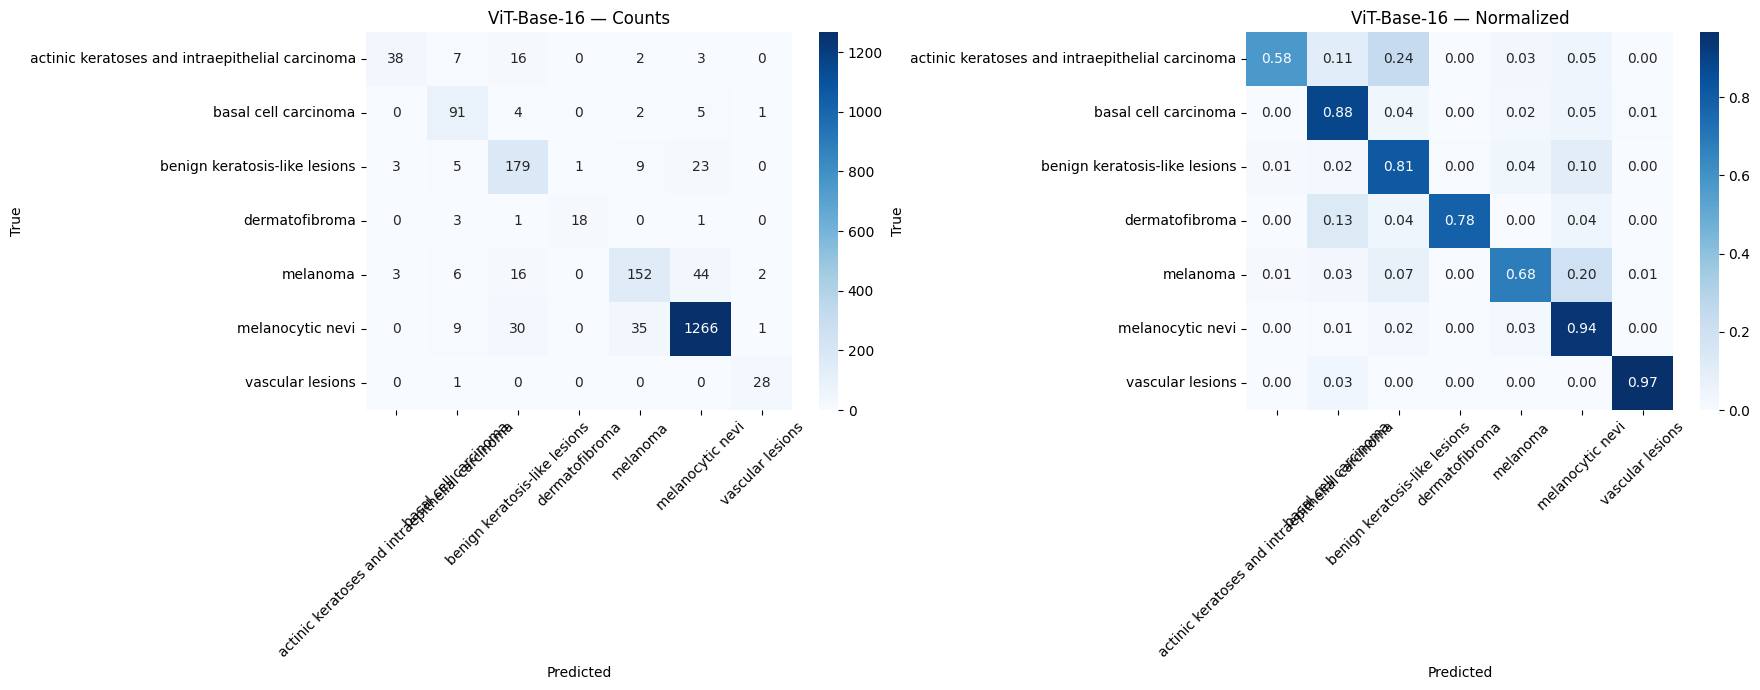


ARCHITECTURE COMPARISON
ResNet-18    Test Accuracy : 84.99%
ViT-Base-16  Test Accuracy : 88.38%


In [19]:
plot_confusion_matrix(vit_test_labels, vit_test_preds, class_names, 'ViT-Base-16')

print('\n' + '='*60)
print('ARCHITECTURE COMPARISON')
print('='*60)
print(f'ResNet-18    Test Accuracy : {resnet_test_acc:.2f}%')
print(f'ViT-Base-16  Test Accuracy : {vit_test_acc:.2f}%')
if resnet_train_time and vit_train_time:
    print(f'ResNet-18    Training Time : {resnet_train_time:.1f}s')
    print(f'ViT-Base-16  Training Time : {vit_train_time:.1f}s')
    print(f'ViT/ResNet   Time Ratio    : {vit_train_time/resnet_train_time:.2f}×')
print('='*60)

## 2. Model Explainability

In healthcare, a model that makes correct predictions for the wrong reasons is dangerous. A CNN might learn to key off ruler markings or ink artifacts rather than the lesion itself. Clinicians need to see where the model focuses before they can trust it.

We apply two complementary interpretability techniques:
- **GradCAM** — uses gradients flowing into the final convolutional layer of ResNet-18 to produce a heatmap of spatially important regions.
- **Attention Rollout** — recursively multiplies ViT attention matrices across all layers to approximate each patch's contribution to the [CLS] token decision.

### 2.1 Case Selection

In [20]:
resnet_model.eval()
vit_model.eval()

# Select 5 diagnostic cases from the test set
selected = {"A": None, "B": None, "C": None, "D": None, "E": None}

for images, labels in test_loader:
    images_dev = images.to(CONFIG["device"])
    with torch.no_grad():
        r_preds = resnet_model(images_dev).argmax(1)
        v_preds = vit_model(images_dev).argmax(1)
    for i in range(len(labels)):
        r, v, gt = r_preds[i].item(), v_preds[i].item(), labels[i].item()
        rc, vc = (r == gt), (v == gt)
        if   selected["A"] is None and rc and vc:          selected["A"] = (images[i], labels[i], r, v)
        elif selected["B"] is None and not rc and not vc and r == v: selected["B"] = (images[i], labels[i], r, v)
        elif selected["C"] is None and not rc and not vc and r != v: selected["C"] = (images[i], labels[i], r, v)
        elif selected["D"] is None and rc and not vc:      selected["D"] = (images[i], labels[i], r, v)
        elif selected["E"] is None and not rc and vc:      selected["E"] = (images[i], labels[i], r, v)
        if all(v is not None for v in selected.values()): break
    if all(v is not None for v in selected.values()): break

print("Selected cases:")
for key, (img, lbl, r, v) in selected.items():
    print(f"  {key}: true={class_names[lbl.item()]:25s}  resnet={class_names[r]:25s}  vit={class_names[v]}")

Selected cases:
  A: true=melanocytic nevi           resnet=melanocytic nevi           vit=melanocytic nevi
  B: true=melanoma                   resnet=melanocytic nevi           vit=melanocytic nevi
  C: true=melanocytic nevi           resnet=benign keratosis-like lesions  vit=basal cell carcinoma
  D: true=melanocytic nevi           resnet=melanocytic nevi           vit=melanoma
  E: true=actinic keratoses and intraepithelial carcinoma  resnet=benign keratosis-like lesions  vit=actinic keratoses and intraepithelial carcinoma


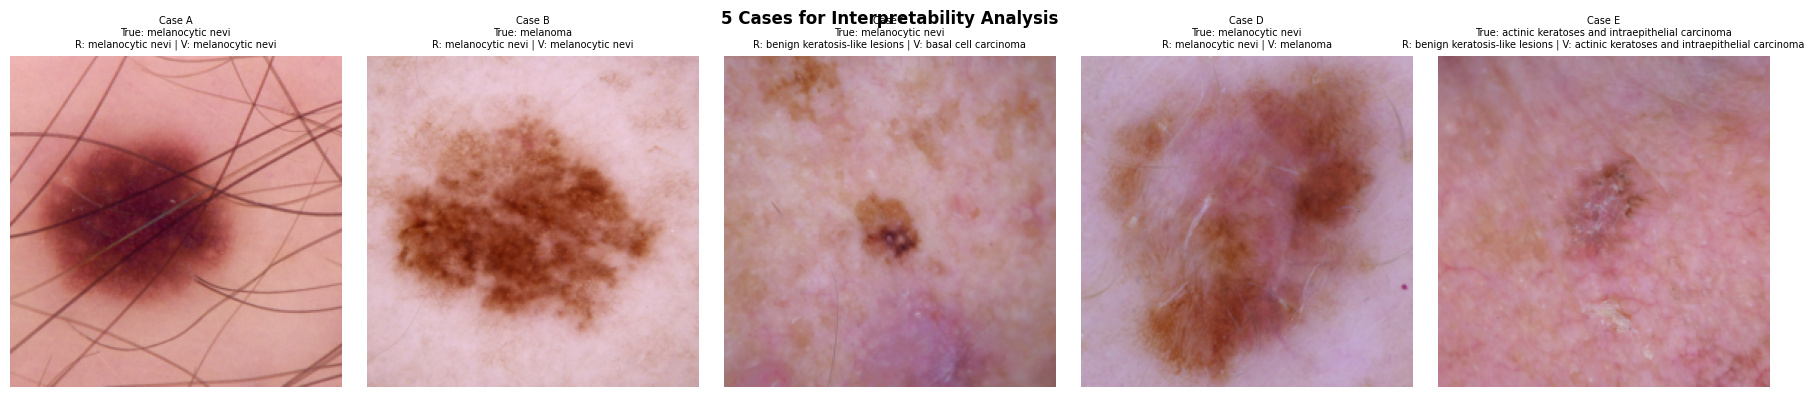

In [21]:
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225])

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (key, (img, lbl, r, v)) in zip(axes, selected.items()):
    img_np = np.clip(inv_normalize(img).permute(1,2,0).numpy(), 0, 1)
    ax.imshow(img_np)
    ax.set_title(f"Case {key}\nTrue: {class_names[lbl.item()]}\n"
                 f"R: {class_names[r]} | V: {class_names[v]}", fontsize=7)
    ax.axis("off")
plt.suptitle("5 Cases for Interpretability Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "selected_images.png"), dpi=150, bbox_inches="tight")
plt.show()

**Case legend**
| Case | Meaning |
|---|---|
| A | Both models correct |
| B | Both models wrong, same incorrect prediction |
| C | Both models wrong, different incorrect predictions |
| D | ResNet correct, ViT wrong |
| E | ViT correct, ResNet wrong |

### 2.2 GradCAM — ResNet-18

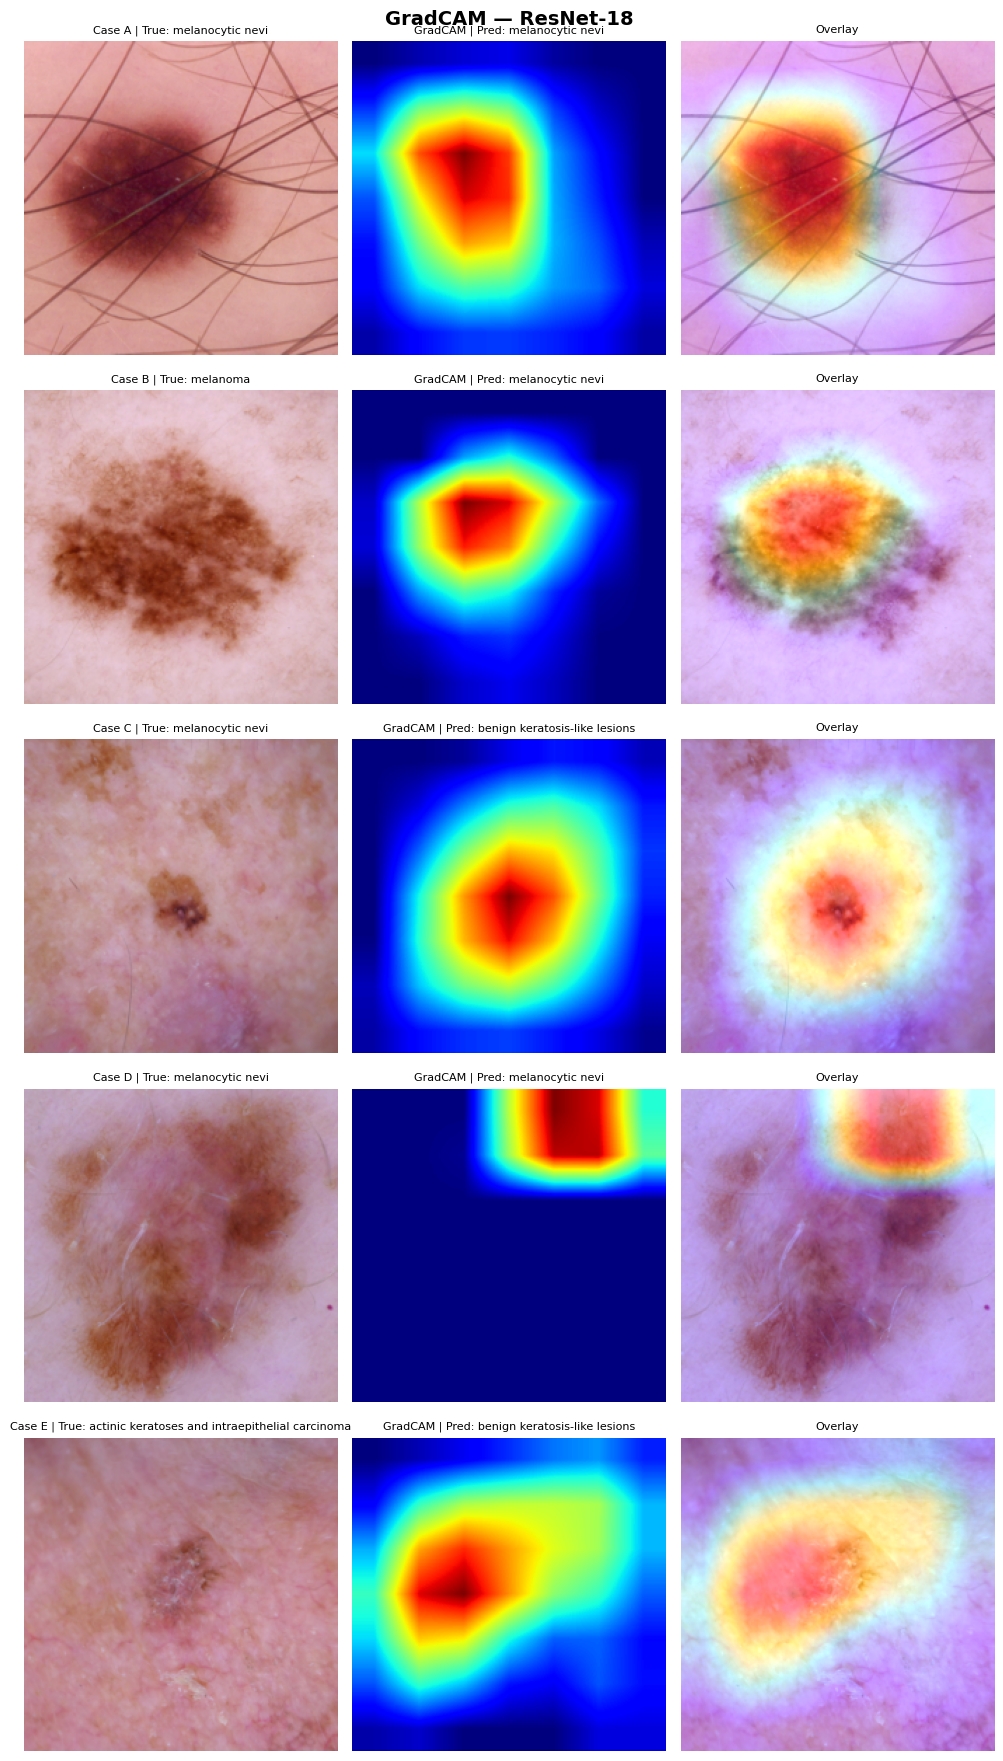

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(CONFIG["device"])
        output = self.model(img_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_gradcam(img_tensor, cam, alpha=0.4):
    img_np = np.clip(inv_normalize(img_tensor).permute(1,2,0).numpy(), 0, 1)
    cam_r  = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
    return img_np, cam_r, np.clip(img_np + alpha * heatmap, 0, 1)


gradcam = GradCAM(resnet_model, resnet_model.layer4[-1].conv2)

fig, axes = plt.subplots(5, 3, figsize=(10, 18))
for row, (key, (img, lbl, r_pred, v_pred)) in enumerate(selected.items()):
    cam, pred_cls = gradcam(img)
    orig, heatmap_2d, overlay = overlay_gradcam(img, cam)
    axes[row, 0].imshow(orig);             axes[row, 0].set_title(f"Case {key} | True: {class_names[lbl.item()]}", fontsize=8); axes[row, 0].axis("off")
    axes[row, 1].imshow(heatmap_2d, cmap="jet"); axes[row, 1].set_title(f"GradCAM | Pred: {class_names[pred_cls]}", fontsize=8); axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay);          axes[row, 2].set_title("Overlay", fontsize=8); axes[row, 2].axis("off")

plt.suptitle("GradCAM — ResNet-18", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "gradcam_visualizations.png"), dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Attention Rollout — ViT-Base-16

In [23]:
class ViTAttentionRollout:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.attention_maps = []
        self.hooks = []
        for i, layer in enumerate(model.encoder.layers):
            self.hooks.append(layer.self_attention.register_forward_hook(self._make_hook(i)))

    def _make_hook(self, layer_id):
        def hook(module, input, output):
            self.attention_maps.append(output[1].detach().cpu())
        return hook

    def __call__(self, img_tensor):
        self.attention_maps = []
        with torch.no_grad():
            _ = self.model(img_tensor)
        return self.attention_maps

    def remove_hooks(self):
        for h in self.hooks: h.remove()


def forward_with_attn_weights(self, query, key, value, key_padding_mask=None,
                               need_weights=False, attn_mask=None, average_attn_weights=True):
    return torch.nn.MultiheadAttention.forward(
        self, query, key, value, key_padding_mask=key_padding_mask,
        need_weights=True, attn_mask=attn_mask, average_attn_weights=average_attn_weights)

import functools
for block in vit_model.encoder.layers:
    block.self_attention.forward = functools.partial(forward_with_attn_weights, block.self_attention)


def compute_rollout(attention_maps):
    result = None
    for attn in attention_maps:
        attn_avg = attn.squeeze(0).mean(0)
        attn_avg = attn_avg + torch.eye(attn_avg.size(0))
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        result = attn_avg if result is None else torch.matmul(attn_avg, result)
    rollout = result[0, 1:]
    rollout = (rollout - rollout.min()) / (rollout.max() - rollout.min() + 1e-8)
    return rollout

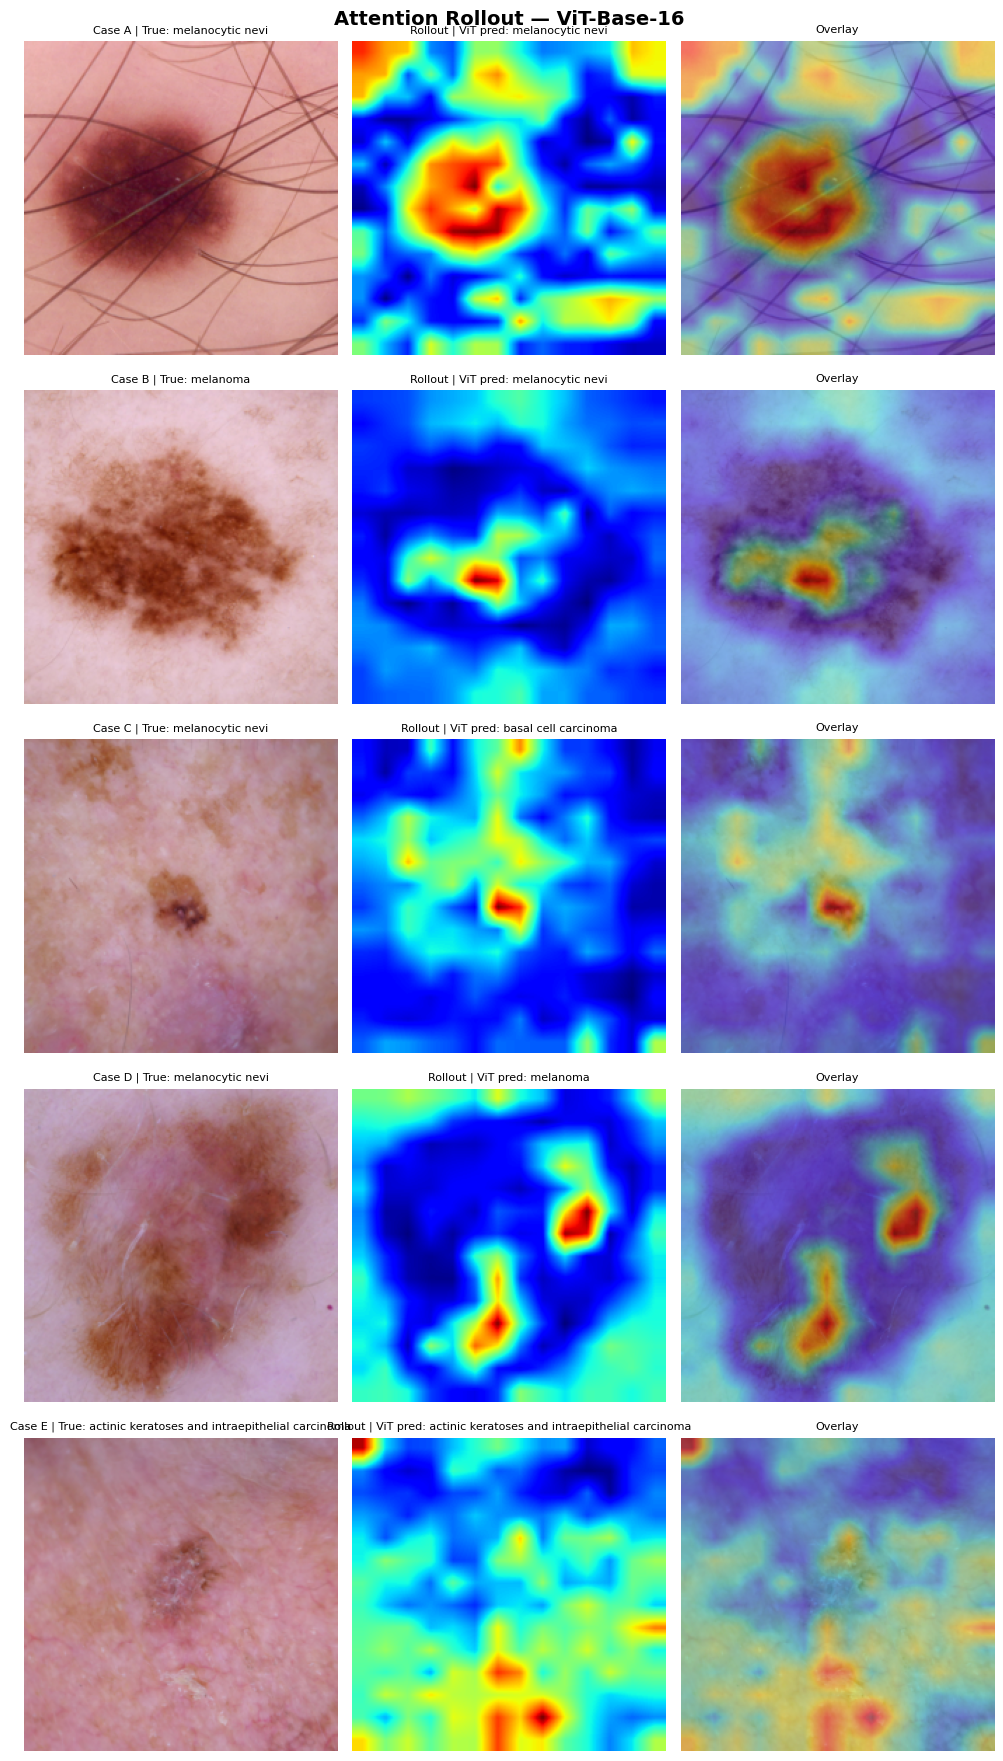

In [24]:
rollout_capturer = ViTAttentionRollout(vit_model)

fig, axes = plt.subplots(5, 3, figsize=(10, 18))
for row, (key, (img, lbl, r_pred, v_pred)) in enumerate(selected.items()):
    attn_maps = rollout_capturer(img.unsqueeze(0).to(CONFIG["device"]))
    rollout   = compute_rollout(attn_maps)

    with torch.no_grad():
        vit_pred = vit_model(img.unsqueeze(0).to(CONFIG["device"])).argmax(1).item()

    img_np   = np.clip(inv_normalize(img).permute(1,2,0).numpy(), 0, 1)
    grid     = int(np.sqrt(rollout.shape[0]))
    rollup   = F.interpolate(
        rollout.reshape(grid, grid).unsqueeze(0).unsqueeze(0).float(),
        size=(224, 224), mode="bilinear", align_corners=False).squeeze().numpy()

    axes[row, 0].imshow(img_np);  axes[row, 0].set_title(f"Case {key} | True: {class_names[lbl.item()]}", fontsize=8); axes[row, 0].axis("off")
    axes[row, 1].imshow(rollup, cmap="jet"); axes[row, 1].set_title(f"Rollout | ViT pred: {class_names[vit_pred]}", fontsize=8); axes[row, 1].axis("off")
    axes[row, 2].imshow(img_np); axes[row, 2].imshow(rollup, cmap="jet", alpha=0.45); axes[row, 2].set_title("Overlay", fontsize=8); axes[row, 2].axis("off")

rollout_capturer.remove_hooks()
plt.suptitle("Attention Rollout — ViT-Base-16", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "attention_rollout_visualizations.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Medical LLM Fine-Tuning with LoRA

Vision models excel at pattern recognition but cannot reason or explain. For patient consultation, the system needs natural language understanding and domain knowledge.

We fine-tune **Gemma-3-270M-IT** — Google's 270M-parameter instruction-tuned model — on **MedMCQA**, a dataset of 194k+ medical entrance exam questions. Rather than full fine-tuning (prohibitively expensive at scale), we use **LoRA (Low-Rank Adaptation)**, which injects trainable low-rank matrices into selected attention layers and leaves the base weights frozen. This reduces trainable parameters by ~97% while preserving model quality.

### 3.1 Setup

In [25]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer
from datasets import load_dataset, DatasetDict
import wandb, os, re, json, random
import numpy as np
from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.12.0 | CUDA: False


In [26]:
base_dir = "./outputs"
os.makedirs(base_dir, exist_ok=True)

In [27]:
from huggingface_hub import login
hf_token = os.environ.get("HF_TOKEN", "")
if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("Logged in to Hugging Face.")
else:
    print("HF_TOKEN not set — set it via: export HF_TOKEN=hf_...")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to Hugging Face.


In [28]:
wandb_key = os.environ.get("WANDB_API_KEY", "")
if wandb_key:
    wandb.login(key=wandb_key)
    print("Logged in to W&B.")
else:
    os.environ["WANDB_MODE"] = "disabled"
    print("W&B logging disabled.")

W&B logging disabled.


### 3.2 Dataset: MedMCQA

MedMCQA contains 194k+ multiple-choice questions from medical entrance exams across 21 subjects (Anatomy, Pharmacology, Surgery, etc.). We keep single-choice questions and downsample to 10,000 training / 1,000 validation examples for tractable fine-tuning.

Questions are reformatted into **Alpaca-style** instruction tuples so the model learns to follow a consistent prompt structure.

In [29]:
def format_medmcqa_to_instruction(example):
    cop = example["cop"]
    try:
        idx = max(0, min(3, int(str(cop).strip())))
    except (ValueError, TypeError):
        idx = max(0, min(3, ord(str(cop).strip().upper()[0]) - ord("A")))
    answer_letter = ["A", "B", "C", "D"][idx]
    choices_str = "\n".join([f"A: {example['opa']}", f"B: {example['opb']}",
                              f"C: {example['opc']}", f"D: {example['opd']}"])
    return {
        "instruction": "Answer the following multiple choice question. Choose the best answer (A, B, C, or D).",
        "input":       f"{example['question']}\n\n{choices_str}",
        "output":      answer_letter,
    }

In [30]:
raw = load_dataset("openlifescienceai/medmcqa")
train_single = raw["train"].filter(lambda x: x["choice_type"] == "single")
val_single   = raw["validation"].filter(lambda x: x["choice_type"] == "single")

dataset = DatasetDict({
    "train":      train_single.shuffle(seed=42).select(range(min(10000, len(train_single)))),
    "validation": val_single.shuffle(seed=42).select(range(min(1000,  len(val_single)))),
    "test":       val_single.shuffle(seed=42).select(range(min(1000,  len(val_single)))),
})
formatted_dataset = dataset.map(format_medmcqa_to_instruction)
print(f"Dataset sizes: {dict((k, len(v)) for k, v in formatted_dataset.items())}")
print("\nExample:", formatted_dataset["train"][0])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset sizes: {'train': 10000, 'validation': 1000, 'test': 1000}

Example: {'id': '012fd9ee-9ff4-44f8-8c58-ee689e29c798', 'question': 'Apolipoprotein A-I (Apo A-I) is found in which of the following lipid components?', 'opa': 'LDL', 'opb': 'HDL', 'opc': 'VLDL', 'opd': 'Chylomicron', 'cop': 1, 'choice_type': 'single', 'exp': 'About Apo A Apo A-I is impoant component of HDL. ApoA is the activator of LCAT which is impoant enzyme for reverse cholesterol transpo, conveing cholesterol to cholesterol ester. Intestinal cells produce small qualntities of Apo A Apo A-I is a ligand for HDL receptor Apo A-I is anti-aherogenic. Ref: Textbook of Biochemistry for Medical Students by D.M. Vasudevan, 6th Edition, Page: 152', 'subject_name': 'Biochemistry', 'topic_name': None, 'instruction': 'Answer the following multiple choice question. Choose the best answer (A, B, C, or D).', 'input': 'Apolipoprotein A-I (Apo A-I) is found in which of the following lipid components?\n\nA: LDL\nB: HDL\nC: VLDL\nD: C

### 3.3 Baseline: Gemma-3-270M-IT (zero-shot)

In [31]:
import glob
model_name   = "google/gemma-3-270m-it"
gemmaft_dir  = os.path.join(base_dir, "gemma_lora")
skip_part3   = bool(glob.glob(os.path.join(gemmaft_dir, "checkpoint-*")))

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="right")
tokenizer.pad_token = tokenizer.eos_token

if not skip_part3:
    model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
    print(f"Loaded {model_name}")
else:
    model = None
    print("LoRA checkpoint found — skipping base model load.")

LoRA checkpoint found — skipping base model load.


In [32]:
def generate_response(model, tokenizer, prompt, max_new_tokens=32):
    messages = [{"role": "user", "content": prompt}]
    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 temperature=0.1, top_p=0.9, do_sample=True,
                                 pad_token_id=tokenizer.pad_token_id,
                                 eos_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)


def extract_answer(response):
    match = re.search(r'\b([A-D])\b', response.strip().upper())
    return match.group(1) if match else None


def evaluate_llm(model, tokenizer, dataset, output_path):
    results, correct = [], 0
    for example in tqdm(dataset, desc="Evaluating"):
        prompt   = example["instruction"] + (f"\n\n{example['input']}" if example.get("input") else "")
        response = generate_response(model, tokenizer, prompt, max_new_tokens=16)
        pred     = next((c for c in response.strip().upper() if c in "ABCD"), None)
        gt       = example["output"].strip().upper()
        is_correct = (pred == gt)
        if is_correct: correct += 1
        results.append({"response": response, "predicted": pred, "ground_truth": gt, "correct": is_correct})
    accuracy = 100.0 * correct / len(dataset)
    print(f"Accuracy: {accuracy:.2f}% ({correct}/{len(dataset)})")
    with open(output_path, "w") as f:
        json.dump({"accuracy": accuracy, "results": results}, f, indent=2)
    return results, accuracy

In [33]:
baseline_path = os.path.join(base_dir, "gemma_results.json")
sub_val = formatted_dataset["test"].shuffle(seed=42).select(range(100))

if skip_part3 and os.path.exists(baseline_path):
    with open(baseline_path) as f:
        saved = json.load(f)
    base_accuracy = saved["accuracy"]
    print(f"Baseline accuracy (from disk): {base_accuracy:.2f}%")
else:
    _, base_accuracy = evaluate_llm(model, tokenizer, sub_val, baseline_path)

Baseline accuracy (from disk): 22.00%


### 3.4 LoRA Fine-Tuning

**LoRA configuration rationale:**
- `r=16` — rank 16 gives a good balance between capacity and parameter efficiency.
- `lora_alpha=32` — alpha/rank = 2 is a standard scaling convention.
- Targeting all attention projection layers (`q/k/v/o_proj`) ensures the model can adapt its attention patterns to medical terminology.
- `lora_dropout=0.05` — light regularisation against overfitting on the 10k subset.

In [34]:
def format_to_gemma(example, tokenizer):
    user_prompt = example['instruction'] + (f"\n\n{example['input']}" if example['input'] and example['input'].strip() else "")
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": user_prompt}], tokenize=False, add_generation_prompt=True)
    bos = tokenizer.bos_token or "<bos>"
    if prompt.startswith(bos): prompt = prompt[len(bos):]
    completion = example['output'] + "<end_of_turn>\n" + (tokenizer.eos_token or "<eos>")
    return {"prompt": prompt, "completion": completion}

In [35]:
if not skip_part3:
    lora_config = LoraConfig(
        r=16, lora_alpha=32,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
    print("LoraConfig ready.")
else:
    print("Skipping LoraConfig — checkpoint already exists.")

Skipping LoraConfig — checkpoint already exists.


In [36]:
from functools import partial

os.makedirs(gemmaft_dir, exist_ok=True)
os.environ["WANDB_MODE"] = "disabled"

if skip_part3:
    print(f"Skipping LoRA training — checkpoint exists in {gemmaft_dir}")
else:
    fmt = partial(format_to_gemma, tokenizer=tokenizer)
    gemma_train = formatted_dataset["train"].map(fmt).map(lambda x: {"text": x["prompt"] + x["completion"]})
    gemma_val   = formatted_dataset["validation"].map(fmt).map(lambda x: {"text": x["prompt"] + x["completion"]})

    sft_config = SFTConfig(
        output_dir=gemmaft_dir, num_train_epochs=2,
        per_device_train_batch_size=4, gradient_accumulation_steps=4,
        learning_rate=2e-4, warmup_ratio=0.05, lr_scheduler_type="cosine",
        logging_steps=50, save_strategy="epoch", eval_strategy="epoch",
        save_total_limit=2, load_best_model_at_end=True,
        report_to="none", dataset_text_field="text", max_length=512,
        fp16=False, bf16=False)

    trainer = SFTTrainer(
        model=model, args=sft_config,
        train_dataset=gemma_train, eval_dataset=gemma_val,
        peft_config=lora_config)

    print("Starting LoRA fine-tuning...")
    trainer.train()
    trainer.save_model(gemmaft_dir)
    print(f"Fine-tuned model saved to {gemmaft_dir}")

Skipping LoRA training — checkpoint exists in ./outputs/gemma_lora


### 3.5 Results: Baseline vs. Fine-Tuned

In [37]:
peft_path = os.path.join(base_dir, "peft_gemma_results.json")

if skip_part3 and os.path.exists(peft_path):
    with open(peft_path) as f:
        saved_ft = json.load(f)
    ft_accuracy = saved_ft["accuracy"]
    print(f"Fine-tuned accuracy (from disk): {ft_accuracy:.2f}%")
else:
    checkpoints  = sorted(glob.glob(os.path.join(gemmaft_dir, "checkpoint-*")))
    ckpt_path    = checkpoints[-1] if checkpoints else gemmaft_dir
    ft_model     = AutoModelForCausalLM.from_pretrained(ckpt_path, device_map="auto")
    ft_tokenizer = AutoTokenizer.from_pretrained(ckpt_path, padding_side="right")
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
    _, ft_accuracy = evaluate_llm(ft_model, ft_tokenizer, sub_val, peft_path)

print("\n" + "="*50)
print("LLM COMPARISON (100-sample eval)")
print("="*50)
print(f"Baseline Gemma-3-270M-IT : {base_accuracy:.2f}%")
print(f"LoRA fine-tuned           : {ft_accuracy:.2f}%")
print(f"Improvement               : {ft_accuracy - base_accuracy:+.2f}%")
print("="*50)

Fine-tuned accuracy (from disk): 53.00%

LLM COMPARISON (100-sample eval)
Baseline Gemma-3-270M-IT : 22.00%
LoRA fine-tuned           : 53.00%
Improvement               : +31.00%


## 4. RAG Pipeline for Real-Time Medical Knowledge

Even a well-fine-tuned LLM has a knowledge cutoff and can hallucinate specific clinical figures. In fast-moving domains like oncology, a model's internal weights may lag months behind the latest guidelines.

We address this with **Retrieval-Augmented Generation (RAG)**: at query time, the system searches a vector index of recent medical papers for relevant passages and injects them as context before calling the LLM. The model no longer needs to memorize facts — it reads them.

**Pipeline:**
1. Load documents → split into overlapping chunks → embed with `BAAI/bge-small-en-v1.5`
2. Store embeddings in a `VectorStoreIndex` (LlamaIndex)
3. At query time: embed the question, retrieve top-k chunks by cosine similarity
4. Pass `[context] + [question]` to `gemma3:4b` via Ollama for generation

### 4.1 Dependencies & Ollama Setup

In [38]:
import subprocess
subprocess.run(["pip", "install", "-q", "llama-index", "llama-index-llms-ollama",
                "llama-index-embeddings-huggingface", "sentence-transformers", "pypdf"],
               capture_output=True)
print("Packages ready.")

Packages ready.


In [39]:
import os
from pathlib import Path
from typing import Optional
from dataclasses import dataclass
import torch

from llama_index.core import (
    VectorStoreIndex, SimpleDirectoryReader, Settings, StorageContext,
    Document, Response, load_index_from_storage)
from llama_index.core.node_parser import SentenceSplitter
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
print("Imports done.")

Imports done.


In [40]:
base_dir = "./outputs"
os.makedirs(base_dir, exist_ok=True)

In [41]:
import subprocess, threading, time

def run_ollama_serve():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

thread = threading.Thread(target=run_ollama_serve, daemon=True)
thread.start()
time.sleep(3)

result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
print(result.stdout)

NAME                        ID              SIZE      MODIFIED     
mxbai-embed-large:latest    468836162de7    669 MB    4 months ago    
gemma3:4b                   a2af6cc3eb7f    3.3 GB    4 months ago    



### 4.2 Pipeline Configuration

In [42]:
@dataclass
class ModelConfig:
    generation_model : str   = "gemma3:4b"
    embedding_model  : str   = "BAAI/bge-small-en-v1.5"
    max_new_tokens   : int   = 512
    temperature      : float = 0.1
    context_window   : int   = 4096
    ollama_base_url  : str   = "http://localhost:11434"
    request_timeout  : float = 120.0

model_config = ModelConfig()
print(f"Generation model : {model_config.generation_model}")
print(f"Embedding model  : {model_config.embedding_model}")

Generation model : gemma3:4b
Embedding model  : BAAI/bge-small-en-v1.5


In [43]:
Settings.llm = Ollama(
    model=model_config.generation_model,
    base_url=model_config.ollama_base_url,
    request_timeout=model_config.request_timeout,
    temperature=model_config.temperature,
    context_window=model_config.context_window,
    num_predict=model_config.max_new_tokens)

Settings.embed_model = HuggingFaceEmbedding(
    model_name=model_config.embedding_model,
    device="cuda" if torch.cuda.is_available() else "cpu")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [44]:
@dataclass
class RAGConfig:
    chunk_size    : int
    chunk_overlap : int

rag_config = RAGConfig(chunk_size=512, chunk_overlap=50)

### 4.3 Indexing & Query Engine

In [45]:
def load_documents(documents_dir: str) -> list:
    documents = SimpleDirectoryReader(documents_dir).load_data()
    print(f"Loaded {len(documents)} chunks from {documents_dir}")
    for doc in documents[:3]:
        print(f"  - {doc.metadata.get('file_name', 'unknown')} ({len(doc.text)} chars)")
    return documents

documents = load_documents("./documents")

Loaded 2 chunks from ./documents
  - breast_cancer_netherlands.txt (3003 chars)
  - skin_cancer_ai.txt (3252 chars)


In [46]:
def ingest_documents(documents: list, rag_config: RAGConfig, save_index: bool = True):
    splitter = SentenceSplitter(chunk_size=rag_config.chunk_size,
                                chunk_overlap=rag_config.chunk_overlap)
    persist_dir     = os.path.join(base_dir, "rag_index")
    storage_context = StorageContext.from_defaults()
    vector_index    = VectorStoreIndex.from_documents(
        documents, transformations=[splitter],
        storage_context=storage_context, show_progress=True)
    if save_index:
        vector_index.storage_context.persist(persist_dir=persist_dir)
        print(f"Index saved to {persist_dir}")
    return vector_index

t0 = time.time()
index_persist_dir = os.path.join(base_dir, "rag_index")

if os.path.exists(index_persist_dir):
    storage_context = StorageContext.from_defaults(persist_dir=index_persist_dir)
    vector_index = load_index_from_storage(storage_context)
    print(f"Loaded existing index from {index_persist_dir}")
else:
    vector_index = ingest_documents(documents, rag_config, save_index=True)

print(f"Index ready in {time.time()-t0:.2f}s")

Loaded existing index from ./outputs/rag_index
Index ready in 0.26s


In [47]:
def get_query_engine(vector_index: VectorStoreIndex, top_k: int = 3):
    return vector_index.as_query_engine(similarity_top_k=top_k, response_mode="compact")

query_engine = get_query_engine(vector_index, top_k=3)
print("Query engine ready.")

Query engine ready.


In [48]:
def query_with_rag(query: str, query_engine=query_engine) -> Response:
    return query_engine.query(query)

query = "How many women are diagnosed with invasive breast cancer each year in the Netherlands?"
print(f"Query: {query}\n")
resp  = query_with_rag(query)
print(f"Response: {resp.response}")

Query: How many women are diagnosed with invasive breast cancer each year in the Netherlands?

Response: Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands.


In [49]:
def display_response(response: Response):
    print("=" * 50)
    print("Response:")
    print(str(response))
    print("=" * 50)
    print("\nSource nodes:")
    for src in response.source_nodes:
        print(f"  Score: {src.score:.4f} | File: {src.metadata.get('file_name', '?')}")
        print(f"  {src.node.get_text()[:200]}...")
        print()

display_response(resp)

Response:
Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands.

Source nodes:
  Score: 0.8578 | File: breast_cancer_netherlands.txt
  Breast Cancer in the Netherlands: Epidemiology and Statistics

Breast cancer is the most common cancer among women in the Netherlands. Approximately 14,000 women are diagnosed with invasive breast can...

  Score: 0.7159 | File: breast_cancer_netherlands.txt
  Recent advances in PARP inhibitors and immunotherapy have shown promise for TNBC treatment.

Metastatic Breast Cancer
Approximately 6-10% of patients present with metastatic disease at diagnosis (de n...

  Score: 0.5828 | File: skin_cancer_ai.txt
  Dataset Challenges
Medical imaging datasets are typically small and imbalanced. The DermaMNIST training set contains approximately 7,000 images with significant class imbalance — melanocytic nevi are ...



### 4.4 Retrieval Hyperparameter Search

In [50]:
import time

test_query = "How many women are diagnosed with invasive breast cancer each year in the Netherlands?"
results    = []

for chunk_size, chunk_overlap in [(256, 20), (512, 50), (1024, 100)]:
    cfg  = RAGConfig(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    t0   = time.time()
    idx  = ingest_documents(documents, cfg, save_index=False)
    idx_t = time.time() - t0
    qe   = get_query_engine(idx, top_k=3)
    t0   = time.time()
    r    = qe.query(test_query)
    gen_t = time.time() - t0
    results.append(dict(chunk_size=chunk_size, overlap=chunk_overlap,
                        index_s=idx_t, gen_s=gen_t, response=r.response[:150]))
    print(f"chunk={chunk_size:4d} overlap={chunk_overlap:3d} | index={idx_t:.1f}s gen={gen_t:.1f}s")
    print(f"  {r.response[:120]}...\n")

print("Selected: chunk_size=512, overlap=50 — balances context coherence and retrieval speed.")

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/6 [00:00<?, ?it/s]

chunk= 256 overlap= 20 | index=3.0s gen=1.5s
  Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands....



Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

chunk= 512 overlap= 50 | index=0.1s gen=1.9s
  Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands....



Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

chunk=1024 overlap=100 | index=0.1s gen=2.4s
  Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands....

Selected: chunk_size=512, overlap=50 — balances context coherence and retrieval speed.


### 4.5 RAG vs. Direct LLM

In [51]:
def query_without_rag(query: str, llm=Settings.llm) -> str:
    return llm.complete(query).text

def compare_rag_vs_llm(questions: list, n: int = 3):
    print("=" * 70)
    for item in questions[:n]:
        q, expected = item["question"], item["answer"]
        print(f"Q: {q}")
        print(f"Expected : {expected}")
        print(f"No RAG   : {query_without_rag(q)[:200]}")
        print(f"With RAG : {query_with_rag(q, query_engine).response[:200]}")
        print("-" * 70)

In [52]:
test_questions = [
    {"question": "How many women are diagnosed with invasive breast cancer each year in the Netherlands?",
     "answer": "Approximately 14,000 women per year."},
    {"question": "What is the average age of a woman at the time of a breast cancer diagnosis in the Netherlands?",
     "answer": "Approximately 61 years."},
    {"question": "How many people worldwide died from cancer in 2020?",
     "answer": "Nearly 10 million deaths — approximately 1 in 6 of all global deaths."},
    {"question": "What proportion of cancer deaths are attributed to common lifestyle risk factors?",
     "answer": "Around one-third, linked to tobacco, high BMI, alcohol, poor diet, and physical inactivity."},
    {"question": "What are acute reversible side effects of chemotherapy?",
     "answer": "Alopecia, nausea, vomiting, fatigue, and myelosuppression."},
]

compare_rag_vs_llm(test_questions, n=3)

Q: How many women are diagnosed with invasive breast cancer each year in the Netherlands?
Expected : Approximately 14,000 women per year.
No RAG   : According to the Dutch National Cancer Registry (CBTN), here's the breakdown of invasive breast cancer diagnoses in the Netherlands each year:

**2022:** Approximately 8,888 women were diagnosed with 
With RAG : Approximately 14,000 women are diagnosed with invasive breast cancer each year in the Netherlands.
----------------------------------------------------------------------
Q: What is the average age of a woman at the time of a breast cancer diagnosis in the Netherlands?
Expected : Approximately 61 years.
No RAG   : According to data from the Dutch Cancer Registry (Kankerregister), the average age of a woman at the time of a breast cancer diagnosis in the Netherlands is approximately **67 years old**.

Here's a m
With RAG : The average age at the time of diagnosis is approximately 61 years.
--------------------------------------------